Commercial Retail Data Analysis

Importing required libraries.

In [57]:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

Loading in the dataset and viewing it to get a general idea.

In [58]:
online_retail = pd.read_csv('online_retail.csv')
online_retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Our objective is to calculate the recency, frequency and monetary value of each customer so that we can determine which customers are of high value and thus are the main target of our strategies.

In [59]:
online_retail.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Performing the initial clean up of the data frame and creating a new cleaned up data frame for future analysis.

In [60]:
clean_retail = online_retail.dropna(subset=['CustomerID'])

In [61]:
clean_retail = clean_retail.loc[(clean_retail['Quantity'] > 0) & (clean_retail['UnitPrice'] > 0), :]
clean_retail.describe()

,Quantity,UnitPrice,CustomerID
count,397884.000000,397884.000000,397884.000000
mean,12.988238,3.116488,15294.423453
std,179.331775,22.097877,1713.141560
min,1.000000,0.001000,12346.000000
25%,2.000000,1.250000,13969.000000
50%,6.000000,1.950000,15159.000000
75%,12.000000,3.750000,16795.000000
max,80995.000000,8142.750000,18287.000000


In [62]:
clean_retail_without_dropped_outliers = clean_retail.copy(deep=True)
clean_retail.drop(index=[540421, 61619], inplace=True)
clean_retail.sort_values(by='Quantity', ascending=False, inplace=True)

Creating a new column 'Total_Price' to find out what was the total price of the order placed by a customer. We did this by using columns 'Quantity' and 'UnitPrice'. We moved on to handle the date in 'InvoiceDate' column which was a series of strings rather than a series of dates. So we handled this issue here.

In [63]:
clean_retail['Total_Price'] = clean_retail['Quantity'] * clean_retail['UnitPrice']
clean_retail['InvoiceDate'] = pd.to_datetime(clean_retail['InvoiceDate'])
clean_retail

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_Price
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,2011-10-27 12:26:00,0.21,12901.0,United Kingdom,1008.00
206121,554868,22197,SMALL POPCORN HOLDER,4300,2011-05-27 10:52:00,0.72,13135.0,United Kingdom,3096.00
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,2011-02-22 10:43:00,0.82,18087.0,United Kingdom,3202.92
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,2011-07-19 17:04:00,0.06,14609.0,United Kingdom,191.16
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749.0,United Kingdom,6539.40
...,...,...,...,...,...,...,...,...,...
180173,552307,21523,DOORMAT FANCY FONT HOME SWEET HOME,1,2011-05-08 15:20:00,7.95,12748.0,United Kingdom,7.95
180174,552307,22442,GROW YOUR OWN FLOWERS SET OF 3,1,2011-05-08 15:20:00,7.95,12748.0,United Kingdom,7.95
180175,552307,82482,WOODEN PICTURE FRAME WHITE FINISH,1,2011-05-08 15:20:00,2.55,12748.0,United Kingdom,2.55
180176,552307,82494L,WOODEN FRAME ANTIQUE WHITE,1,2011-05-08 15:20:00,2.95,12748.0,United Kingdom,2.95


Creating a series 'snapshot_date' (an snapshot date is a prerequisite for determining the recency of the dataset) and a new data frame by the name of 'rfm'.

In [64]:
snapshot_date = clean_retail['InvoiceDate'].max() + dt.timedelta(days=1)
rfm = clean_retail.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Total_Price': 'sum'
})
rfm.rename(columns={'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'Total_Price': 'Monetary'
}, inplace=True)
rfm

,Recency,Frequency,Monetary
CustomerID,,,
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
12352.0,36,8,2506.04
...,...,...,...
18280.0,278,1,180.60
18281.0,181,1,80.82
18282.0,8,2,178.05


Sorting 'rfm' data frame in multiple different ways to analyze the data from the multiple perspectives.

In [65]:
rfm.sort_index(ascending=True, inplace=True)

In [66]:
rfm.sort_values(by='Recency', ascending=False, inplace=False)

,Recency,Frequency,Monetary
CustomerID,,,
18074.0,374,1,489.60
12791.0,374,1,192.60
17968.0,374,1,277.35
16583.0,374,1,233.45
14729.0,374,1,313.49
...,...,...,...
14702.0,1,17,3292.14
17554.0,1,5,1952.45
17581.0,1,25,11045.04


In [67]:
rfm.sort_values(by='Frequency', ascending=False, inplace=False)

,Recency,Frequency,Monetary
CustomerID,,,
12748.0,1,209,33719.73
14911.0,1,201,143825.06
17841.0,2,124,40991.57
13089.0,3,97,58825.83
14606.0,1,93,12156.65
...,...,...,...
13747.0,374,1,79.60
13751.0,288,1,296.25
13753.0,288,1,741.26


In [68]:
rfm.sort_values(by='Monetary', ascending=False, inplace=False)

,Recency,Frequency,Monetary
CustomerID,,,
14646.0,2,73,280206.02
18102.0,1,60,259657.30
17450.0,8,46,194550.79
14911.0,1,201,143825.06
12415.0,24,21,124914.53
...,...,...,...
17956.0,249,1,12.75
16454.0,45,2,6.90
14792.0,64,1,6.20


Creating new columns in 'rfm' data frame and assigning them quantile values.

In [69]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
12347.0,2,7,4310.00,4,4,4
12348.0,75,4,1797.24,2,3,4
12349.0,19,1,1757.55,3,1,4
12350.0,310,1,334.40,1,1,2
12352.0,36,8,2506.04,3,4,4


Creating two more new columns and then sorting 'rfm' data frame.

In [70]:
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)
rfm.sort_values(by=['RFM_Score', 'Monetary'], ascending=False, inplace=True)

Creating a new column and then applying a custom function to it to assign labels to each entry.

In [71]:
def assign_label(score):
    if score >= 10:
        return 'Champions'
    elif score >= 8:
        return 'Loyal Customers'
    elif score >= 6:
        return 'Needs Attention'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost'
rfm['Segment'] = rfm['RFM_Score'].apply(assign_label)
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score,Segment
CustomerID,,,,,,,,,
14646.0,2,73,280206.02,4,4,4,444,12,Champions
18102.0,1,60,259657.30,4,4,4,444,12,Champions
17450.0,8,46,194550.79,4,4,4,444,12,Champions
14911.0,1,201,143825.06,4,4,4,444,12,Champions
14156.0,10,55,117379.63,4,4,4,444,12,Champions


Creating a summary table and performing the final clean up by renaming and sorting the data frame before moving on to visualization.

In [72]:
segment_summary = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Segment': 'count'
}).round(1)
segment_summary.rename(columns={'Segment': 'Total_Customers'}, inplace=True)
segment_summary.sort_values(by='Monetary', ascending=False, inplace=True)
segment_summary.to_excel('rfm_segment_summary.xlsx')

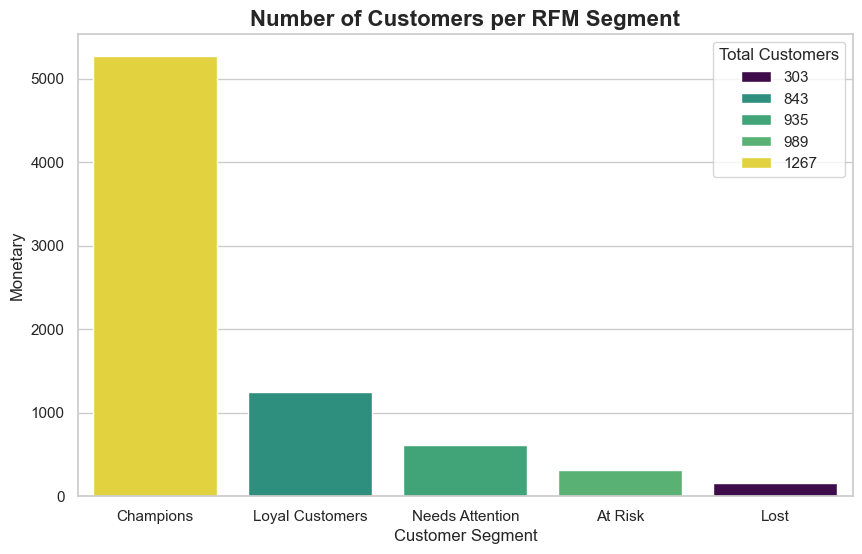

In [73]:
plot_data = segment_summary.reset_index()

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data, x='Segment', y='Monetary', palette='viridis', hue='Total_Customers')

plt.title('Number of Customers per RFM Segment', fontsize=16, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Monetary', fontsize=12)
plt.legend(title='Total Customers', title_fontsize=12)

plt.show()

Conclusion:

- The organization can collect emails of the champions and email them offers and deals before they are announced to the general pubic.
- The organization can make the champions the main target or focal point of all strategies.
- The organization can provide the champions with special loyalty discounts to ensure that the high value customers stay hooked to the organization's services and products.